# Ines tests

In [ ]:
import sys
from pathlib import Path

# Notebook lives in waves2surf_net/notebooks/; package root is the parent dir.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

In [9]:
import matplotlib.pyplot as plt
from ocean_velocity.config import load_config
from ocean_velocity.train import make_dataset

In [ ]:
cfg = load_config(ROOT / "configs" / "agulhas.json")
# override to a tiny window for the smoke test
cfg["data"]["splits"] = {
    "train": {"start": "20230101", "end": "20230102"},
    "validation": {"start": "20230101", "end": "20230101"},
    "test": {"start": "20230102", "end": "20230102"},
}

ds = make_dataset(cfg, "train")
print(len(ds), "samples")
sample = ds[0]
print({k: (v.shape if hasattr(v, "shape") else v) for k, v in sample.items()})

16 samples
{'x': torch.Size([3, 241, 481]), 'y': torch.Size([2, 241, 481]), 'metadata': torch.Size([2]), 'metadata_valid': torch.Size([]), 'valid_mask': torch.Size([1, 241, 481]), 'index': torch.Size([])}


In [10]:
sample.keys()

dict_keys(['x', 'y', 'metadata', 'metadata_valid', 'valid_mask', 'index'])

In [6]:
sample['x'].shape

torch.Size([3, 241, 481])

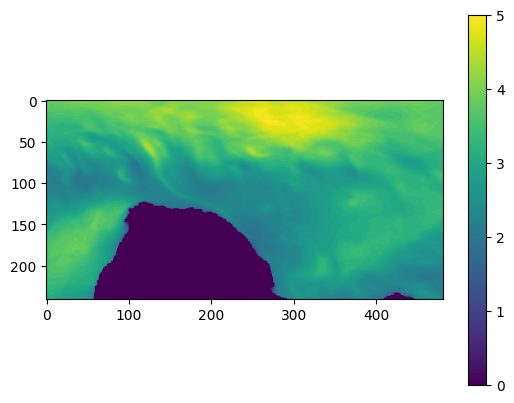

In [14]:
plt.imshow(sample['x'][0, :, :].numpy())
plt.colorbar()

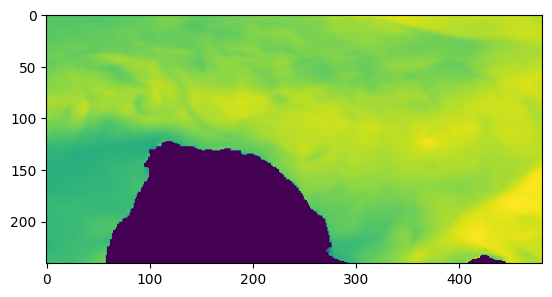

In [13]:
plt.imshow(sample['x'][1, :, :].numpy())

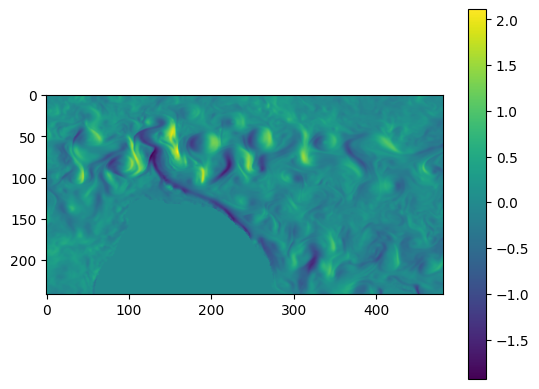

In [16]:
plt.imshow(sample['y'][1, :, :].numpy())
plt.colorbar()

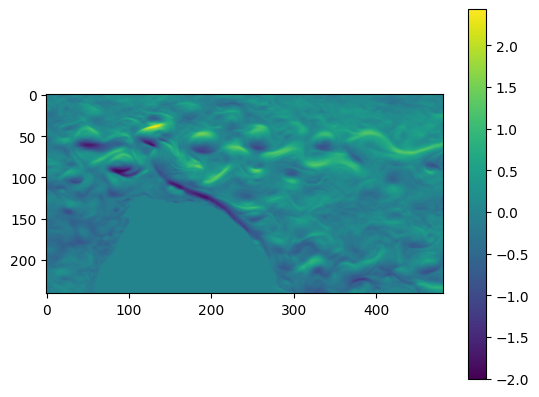

In [17]:
plt.imshow(sample['y'][0, :, :].numpy())
plt.colorbar()